In [119]:
datasets_parameters_files = {
     'mocap': 'datasets/mocap/calculated_parameters_v3.json',
        
     'openpose': 'datasets/openpose/calculated_parameters_openpose_triangulated_v2.json',
        
     'mediapipe': 'datasets/mediapipe/calculated_parameters_v4_triangulated.json',
        
     'hrnet': 'datasets/mmpose/calculated_parameters_hrnet_triangulated.json',
     'rtmpose': 'datasets/mmpose/calculated_parameters_rtmpose_triangulated.json',
     'vitpose': 'datasets/mmpose/calculated_parameters_vitpose_triangulated.json',
        
     'movenet_lightning': 'datasets/movenet/calculated_parameters_lightning_triangulated.json',
     'movenet_thunder': 'datasets/movenet/calculated_parameters_thunder_triangulated.json',
        
     'yolo_v26': 'datasets/yolo/calculated_parameters_v3_yolo26.json',
     'yolo_v11': 'datasets/yolo/calculated_parameters_v2_triangulated_v3.json'
}


formats = {
    'mocap': ['mocap'],
    'body_25': ['openpose'],
    'mediapipe': ['mediapipe'],
    'coco': ['hrnet', 'rtmpose', 'vitpose', 'yolo_v11', 'yolo_v26', 'movenet_lightning', 'movenet_thunder']
}

parameter_names = ['legs_angles', 'left_knee_angles', 'right_knee_angles', 'left_hip_angles', 'right_hip_angles', 
                   'left_humerus_angles', 'right_humerus_angles', 'left_elbow_angles', 'right_elbow_angles', 
                   'ankle_distances', 'knee_distances', 'elbow_distances', 'hand_distances', 
                   'center_of_gravity_height_change', 'lateral_pelvic_tilt', 'pelvis_rotation']


In [2]:
import json

param_ds = {}

for name, file_path in datasets_parameters_files.items():
    print(name)
    with open(file_path, 'r') as file:
        param_ds[name] = json.load(file)


mocap
openpose
mediapipe
hrnet
rtmpose
vitpose
movenet_lightning
movenet_thunder
yolo_v26
yolo_v11


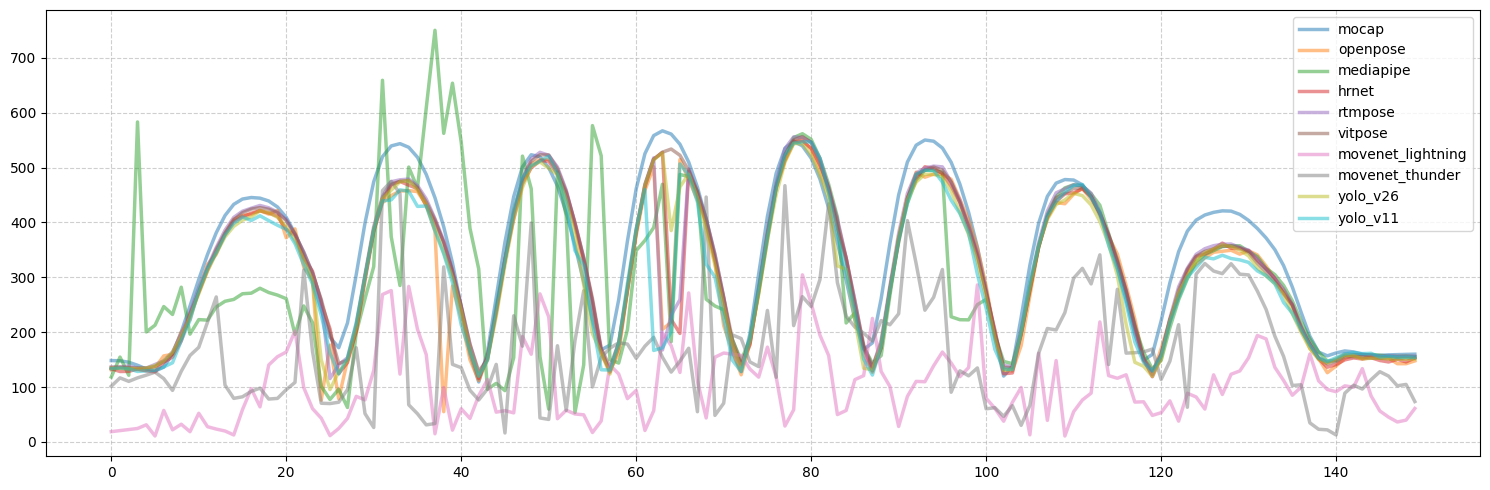

In [41]:
import matplotlib.pyplot as plt
import numpy as np

seq_key = 'p3s3'
param = 'ankle_distances'

plt.figure(figsize=(15, 5))

for name, dataset in param_ds.items():
    plt.plot(
        dataset[seq_key][param],
        # linestyle='dotted',
        linewidth=2.5,
        alpha=0.5,
        label=name
    )

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [57]:
from typing import Sequence

def find_local_maxima(data, window_size: int = 7) -> Sequence[int]:
        local_maxima_indices = []

        for i in range(window_size, len(data) - window_size):
            window_prev = data[i - window_size : i]
            window_next = data[i + 1 : i + window_size + 1]
            current = data[i]

            if current > max(window_prev) and current > max(window_next):
                local_maxima_indices.append(i)

        return local_maxima_indices

In [58]:
for name, dataset in param_ds.items():
    maxima = find_local_maxima(dataset[seq_key][param], window_size=7)
    print(maxima, name)

[16, 33, 48, 63, 78, 93, 109, 127] mocap
[17, 34, 50, 65, 79, 92, 111, 128] openpose
[17, 37, 55, 65, 79, 93, 110, 129] mediapipe
[17, 33, 49, 63, 78, 93, 111, 127] hrnet
[17, 34, 49, 62, 78, 94, 110, 128] rtmpose
[17, 34, 49, 64, 79, 94, 111, 128] vitpose
[21, 34, 49, 66, 79, 99, 113, 131] movenet_lightning
[12, 22, 32, 48, 68, 77, 91, 113, 125] movenet_thunder
[17, 34, 49, 63, 78, 93, 110, 127] yolo_v26
[17, 33, 50, 65, 79, 93, 111, 127] yolo_v11


In [97]:
a_maxima = [19, 35, 51, 66, 82, 97, 114]
b_maxima =[16, 33, 48, 63, 78, 93, 109, 127]

In [103]:
maxima = a_maxima
[int(maxima[2*i] + 0.5 * (maxima[2*i + 2] - maxima[2*i])) for i in range(len(maxima)//2)]

maxima = b_maxima
[int(maxima[2*i] + 0.5 * (maxima[2*i + 2] - maxima[2*i])) for i in range(len(maxima)//2 - 1)]

[32, 63, 93]

In [54]:
len(a_maxima)%2

1

In [55]:
len(b_maxima)%2

0

In [88]:
import re

s = "p1s1"

def get_person_from_seq_key(sequence_key: str) -> int:
    match = re.search(r"p(\d+)s", sequence_key)
    if match:
        person_id = int(match.group(1))
    return int(person_id)

In [112]:
import numpy as np

def get_steps_features(dataset):
    extracted_paramters = {i:[] for i in range(1,33)}
    for sequence_key, sequence_parameters in dataset.items():
        person_id = get_person_from_seq_key(sequence_key)
        maxima = find_local_maxima(sequence_parameters['ankle_distances'])
        if len(maxima)%2:
            stride_centers = [int(maxima[2*i] + 0.5 * (maxima[2*i + 2] - maxima[2*i])) for i in range(len(maxima)//2)]
        else:
            stride_centers = [int(maxima[2*i] + 0.5 * (maxima[2*i + 2] - maxima[2*i])) for i in range(len(maxima)//2 - 1)]
        for c_idx in stride_centers:
            stride_matrix = np.array([sequence_parameters[parameter][c_idx - 16: c_idx + 16] for parameter in parameter_names])
            extracted_paramters[person_id].append(stride_matrix)

    return extracted_paramters


In [116]:
extracted_paramters = get_steps_features(param_ds['mocap'])

for seq_key, parameters in extracted_paramters.items():
    print(f"{seq_key}  : {len(parameters)} parameters")

1  : 10 parameters
2  : 12 parameters
3  : 12 parameters
4  : 8 parameters
5  : 12 parameters
6  : 10 parameters
7  : 11 parameters
8  : 10 parameters
9  : 9 parameters
10  : 12 parameters
11  : 10 parameters
12  : 11 parameters
13  : 10 parameters
14  : 12 parameters
15  : 8 parameters
16  : 12 parameters
17  : 11 parameters
18  : 12 parameters
19  : 11 parameters
20  : 11 parameters
21  : 12 parameters
22  : 12 parameters
23  : 8 parameters
24  : 10 parameters
25  : 8 parameters
26  : 16 parameters
27  : 19 parameters
28  : 26 parameters
29  : 23 parameters
30  : 19 parameters
31  : 22 parameters
32  : 12 parameters


In [117]:
extracted_paramters = get_steps_features(param_ds['yolo_v26'])

for seq_key, parameters in extracted_paramters.items():
    print(f"{seq_key}  : {len(parameters)} parameters")

1  : 10 parameters
2  : 12 parameters
3  : 12 parameters
4  : 8 parameters
5  : 12 parameters
6  : 10 parameters
7  : 11 parameters
8  : 10 parameters
9  : 9 parameters
10  : 11 parameters
11  : 10 parameters
12  : 11 parameters
13  : 10 parameters
14  : 12 parameters
15  : 9 parameters
16  : 12 parameters
17  : 11 parameters
18  : 12 parameters
19  : 11 parameters
20  : 11 parameters
21  : 12 parameters
22  : 13 parameters
23  : 7 parameters
24  : 10 parameters
25  : 8 parameters
26  : 16 parameters
27  : 20 parameters
28  : 26 parameters
29  : 23 parameters
30  : 20 parameters
31  : 21 parameters
32  : 12 parameters


In [118]:
extracted_paramters = get_steps_features(param_ds['vitpose'])

for seq_key, parameters in extracted_paramters.items():
    print(f"{seq_key}  : {len(parameters)} parameters")

1  : 11 parameters
2  : 12 parameters
3  : 12 parameters
4  : 8 parameters
5  : 12 parameters
6  : 10 parameters
7  : 11 parameters
8  : 9 parameters
9  : 9 parameters
10  : 11 parameters
11  : 10 parameters
12  : 11 parameters
13  : 10 parameters
14  : 12 parameters
15  : 8 parameters
16  : 12 parameters
17  : 11 parameters
18  : 12 parameters
19  : 11 parameters
20  : 11 parameters
21  : 12 parameters
22  : 12 parameters
23  : 8 parameters
24  : 10 parameters
25  : 8 parameters
26  : 21 parameters
27  : 25 parameters
28  : 34 parameters
29  : 30 parameters
30  : 24 parameters
31  : 27 parameters
32  : 18 parameters
